### Setup + carga de datos

In [86]:
import pandas as pd
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import numpy as np
from shapely.geometry import LineString
import contextily as ctx

def get_linewidth(weight):
    return np.log1p(weight) * 1.5

In [87]:
df = pd.read_excel("..\data\pacientes.xlsx")

# limpiar Id inválidos
df = df[df["Id"].astype(str).str.match(r"[A-Za-z0-9]+")]

# fechas
date_cols = ["Fecha inicio", "Fecha egreso", "Última actualización"]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")

# duración
df["Duracion días"] = (df["Fecha egreso"] - df["Fecha inicio"]).dt.days

print(df["Motivo"].value_counts())

Motivo
alta-domiciliaria              3880
muerte                          680
traslado-hospital-de-la-red     643
traslado-otro                   600
otro                            565
anulado                         274
traslado-extra-sanitario        251
Name: count, dtype: int64


Cada fila es: una persona estuvo en este hospital, desde tal fecha hasta tal fecha, con este estado, y salió por tal motivo

#### Reconstruccion de los traslados:

In [88]:
# Función para reconstruir traslados
def reconstruir_traslados(df):

    # ordenar
    df = df.sort_values(["Id", "Fecha inicio"]).copy()

    # continuidad temporal
    df["Hospital siguiente"] = df.groupby("Id")["Nombre Hospital"].shift(-1)
    df["Fecha ingreso siguiente"] = df.groupby("Id")["Fecha inicio"].shift(-1)

    # diferencia de días
    df["dias_entre_hospitales"] = (
        df["Fecha ingreso siguiente"] - df["Fecha egreso"]
    ).dt.days

    # marcar traslados explícitos
    df["es_traslado"] = df["Motivo"].str.contains("traslad", case=False, na=False)

    # FILTRADO DEFINITIVO
    traslados = df[
        (df["es_traslado"]) &
        (df["Hospital siguiente"].notna()) &
        (df["Hospital siguiente"] != df["Nombre Hospital"])
    ].copy()


    return traslados


traslados = reconstruir_traslados(df)
print("Traslados confirmados:", len(traslados))

Traslados confirmados: 496


In [89]:
negativos = traslados[traslados["dias_entre_hospitales"] < 0].copy()

print("Cantidad negativos:", len(negativos))
negativos[[
    "Id",
    "Nombre Hospital",
    "Hospital siguiente",
    "Fecha inicio",
    "Fecha egreso",
    "Fecha ingreso siguiente",
    "dias_entre_hospitales"
]].sort_values("dias_entre_hospitales").head(20)

Cantidad negativos: 190


,Id,Nombre Hospital,Hospital siguiente,Fecha inicio,Fecha egreso,Fecha ingreso siguiente,dias_entre_hospitales
6528,1,UPA 17 - QU,Oñativia,2020-05-01 18:07:36,2020-08-03 18:07:36,2020-05-19 18:07:35,-77.0
358,JX46,El Cruce,UPA 11 - FV,2020-09-16 18:07:34,2020-09-29 18:07:34,2020-09-16 18:07:36,-13.0
381,KM44,El Cruce,UPA 11 - FV,2020-09-22 18:07:34,2020-10-01 18:07:34,2020-09-22 18:07:36,-9.0
414,XS83,El Cruce,UPA 11 - FV,2020-10-01 18:07:34,2020-10-10 18:07:34,2020-10-01 18:07:36,-9.0
362,DY79,El Cruce,Mi Pueblo,2020-09-16 18:07:34,2020-09-24 18:07:34,2020-09-16 18:07:34,-8.0
354,DE74,El Cruce,UPA 11 - FV,2020-09-15 18:07:34,2020-09-21 18:07:34,2020-09-15 18:07:36,-6.0
3506,4,Oñativia,UPA 17 - QU,2020-05-31 18:07:35,2020-06-11 18:07:35,2020-06-08 18:07:36,-3.0
3064,OR60,Lucio Meléndez,Módulo Hospitalario 9 - AB,2020-08-07 18:07:35,2020-08-10 18:07:35,2020-08-08 18:07:35,-2.0
4635,UW61,Módulo Hospitalario 9 - AB,UPA 5 - AB,2020-09-20 18:07:35,2020-09-22 18:07:35,2020-09-20 18:07:35,-2.0
4203,XG82,Oñativia,El Cruce,2020-09-13 18:07:35,2020-09-19 18:07:35,2020-09-18 18:07:34,-2.0


In [90]:
peor_id = negativos.sort_values("dias_entre_hospitales").iloc[0]["Id"]
print("Paciente problemático:", peor_id)

traslados[traslados["Id"] == peor_id].sort_values("Fecha inicio")

Paciente problemático: 1


,Id Hospital,Nombre Hospital,Id,Fecha inicio,Estado al ingreso,Tipo al ingreso,Último estado,Último tipo,Sexo,Edad,...,Enfermedades preexistentes,Motivo,Operación,Fecha egreso,Última actualización,Duracion días,Hospital siguiente,Fecha ingreso siguiente,dias_entre_hospitales,es_traslado
6528,147,UPA 17 - QU,1,2020-05-01 18:07:36,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,36,...,diabetes-mellitus,traslado-otro,egreso,2020-08-03 18:07:36,2020-08-04 18:05:01,94.0,Oñativia,2020-05-19 18:07:35,-77.0,True


# Modulo 1: Construccion de red hospitalaria

## a. Exploracion del periodo

In [91]:
traslados_periodo = traslados[
    (traslados["Fecha egreso"] >= "2020-06-01") &
    (traslados["Fecha egreso"] <= "2020-10-31")
]

print("Traslados en periodo:", len(traslados_periodo))
print("Fecha mínima:", traslados["Fecha egreso"].min())
print("Fecha máxima:", traslados["Fecha egreso"].max())
print(traslados["Fecha egreso"].dt.year.value_counts())

Traslados en periodo: 481
Fecha mínima: 2020-06-11 18:07:35
Fecha máxima: 2020-10-29 18:07:34
Fecha egreso
2020.0    481
Name: count, dtype: int64


## b. Generar red

In [92]:
def generar_red(traslados, fecha_inicio, fecha_fin):

    fecha_inicio = pd.to_datetime(fecha_inicio)
    fecha_fin = pd.to_datetime(fecha_fin)

    traslados_periodo = traslados[
        (traslados["Fecha egreso"] >= fecha_inicio) &
        (traslados["Fecha egreso"] <= fecha_fin)
    ].copy()

    edges = (
        traslados_periodo
        .groupby(["Nombre Hospital", "Hospital siguiente"])
        .size()
        .reset_index(name="weight")
    )

    G = nx.DiGraph()

    for _, row in edges.iterrows():
        G.add_edge(
            row["Nombre Hospital"],
            row["Hospital siguiente"],
            weight=row["weight"]
        )

    return G, edges

## c. Cargar coordenadas de hospitales

In [93]:
hosp_coords = pd.read_csv("..\data\hospitales_coordenadas.csv")

hosp_coords["Latitud"] = (
    hosp_coords["Latitud"].astype(str).str.replace(",", ".").astype(float)
)

hosp_coords["Longitud"] = (
    hosp_coords["Longitud"].astype(str).str.replace(",", ".").astype(float)
)

hosp_coords["Nombre Hospital"] = hosp_coords["Nombre Hospital"].str.strip()

## d. Plot simple

In [94]:
def plot_edges_geo(G, hosp_coords, guardar_path=None, titulo="Red hospitalaria", caption=None):
    plt.figure(figsize=(12,12))

    gdf_nodes = gpd.GeoDataFrame(
        hosp_coords,
        geometry=gpd.points_from_xy(
            hosp_coords["Longitud"],
            hosp_coords["Latitud"]
        )
    )

    gdf_nodes.plot(marker="o", color="red", markersize=50, zorder=2)

    coords_dict = hosp_coords.set_index(
        "Nombre Hospital"
    )[["Latitud","Longitud"]].to_dict("index")

    for u, v, d in G.edges(data=True):
        if u not in coords_dict or v not in coords_dict:
            continue
        origen = coords_dict[u]
        destino = coords_dict[v]
        plt.plot(
            [origen["Longitud"], destino["Longitud"]],
            [origen["Latitud"], destino["Latitud"]],
            linewidth=get_linewidth(d["weight"]),
            alpha=0.5
        )

    for _, row in gdf_nodes.iterrows():
        plt.text(
            row["Longitud"],
            row["Latitud"],
            row["Nombre Hospital"],
            fontsize=8,
            ha="right"
        )

    # título
    plt.title(titulo)
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")

    # caption
    if caption is not None:
        plt.figtext(0.5, -0.02, caption, wrap=True, ha='center', fontsize=10)

    if guardar_path:
        plt.tight_layout()
        plt.savefig(guardar_path, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

## e. Ejecutar red por periodo

In [95]:
def red_por_periodo(traslados, fecha_inicio, fecha_fin, hosp_coords):

    G_periodo, edges_periodo = generar_red(
        traslados,
        fecha_inicio,
        fecha_fin
    )

    # chequeo coordenadas faltantes
    nodos_red = set(G_periodo.nodes())
    nodos_coords = set(hosp_coords["Nombre Hospital"])

    faltantes = nodos_red - nodos_coords

    print("Hospitales en red:", len(nodos_red))
    print("Hospitales con coordenadas:", len(nodos_coords))
    print("Sin coordenadas:", len(faltantes))

    plot_edges_geo(G_periodo, hosp_coords)

    return G_periodo, edges_periodo

Hospitales en red: 13
Hospitales con coordenadas: 14
Sin coordenadas: 1


<Figure size 1200x1200 with 0 Axes>

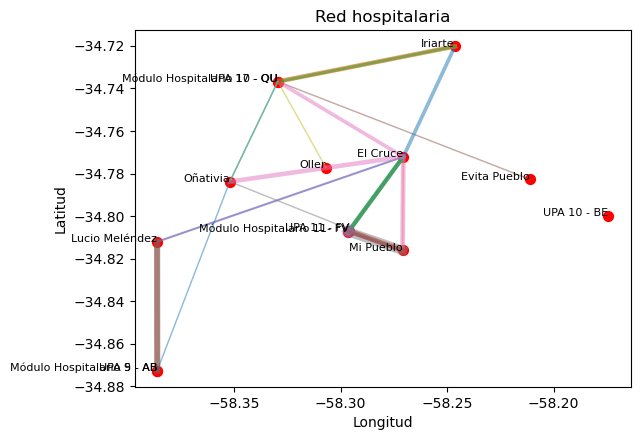

In [96]:
G_periodo, edges_periodo = red_por_periodo(
    traslados,
    "2020-06-01",
    "2020-10-31",
    hosp_coords
)

## f. Plot con mapa

In [97]:
def plot_red_con_mapa(G, hosp_coords):

    gdf_nodes = gpd.GeoDataFrame(
        hosp_coords,
        geometry=gpd.points_from_xy(
            hosp_coords["Longitud"],
            hosp_coords["Latitud"]
        ),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    geom_dict = dict(zip(gdf_nodes["Nombre Hospital"], gdf_nodes.geometry))

    edges_list = []

    for u, v, d in G.edges(data=True):
        if u not in geom_dict or v not in geom_dict:
            continue

        edges_list.append({
            "geometry": LineString([geom_dict[u], geom_dict[v]]),
            "weight": d["weight"]
        })

    gdf_edges = gpd.GeoDataFrame(edges_list, crs="EPSG:3857")

    fig, ax = plt.subplots(figsize=(10,10))

    if len(gdf_edges) > 0:
        gdf_edges.plot(
            ax=ax,
            linewidth=gdf_edges["weight"].apply(get_linewidth),
            alpha=0.6
        )

    gdf_nodes.plot(ax=ax, color="red", markersize=40, zorder=2)

    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

    plt.axis("off")
    plt.show()

In [98]:
# para usar sacar el comentario:
# plot_red_con_mapa(G_periodo, hosp_coords)

## g. Plot con mapa interactivo

In [99]:
def plot_red_interactiva(G, hosp_coords):

    coord_dict = {
        row["Nombre Hospital"]: (row["Latitud"], row["Longitud"])
        for _, row in hosp_coords.iterrows()
    }

    centro = [
        hosp_coords["Latitud"].mean(),
        hosp_coords["Longitud"].mean()
    ]

    m = folium.Map(location=centro, zoom_start=9)

    for nombre, (lat, lon) in coord_dict.items():
        folium.CircleMarker(
            location=[lat, lon],
            radius=6,
            popup=nombre,
            color="red",
            fill=True
        ).add_to(m)

    for u, v, d in G.edges(data=True):

        if u not in coord_dict or v not in coord_dict:
            continue

        folium.PolyLine(
            [coord_dict[u], coord_dict[v]],
            weight=1 + d["weight"] * 0.5,
            color="blue"
        ).add_to(m)

    return m

In [100]:
'''# para usar y guardar, sacar el comentario:
m = plot_red_interactiva(G_periodo, hosp_coords)
m.save("red_hospitalaria.html")'''

'# para usar y guardar, sacar el comentario:\nm = plot_red_interactiva(G_periodo, hosp_coords)\nm.save("red_hospitalaria.html")'

## Funcion generalizada para hacer analisis de red (cambiando los parametros segun necesidad)

Esta función agrupa todo lo que hicimos antes en el notebook: filtra por fechas, arma la red de traslados, y opcionalmente la grafica.  

#### Parámetros clave
- `traslados` : base original  
- `hosp_coords` : solo si voy a graficar  
- `fecha_inicio` / `fecha_fin` : ventana temporal  
- `filtrar_motivo` : qué tipo de eventos incluir  
- `hospital_origen` / `hospital_destino` : filtrar por hospital específico  
- `peso_minimo` : cortar conexiones débiles  
- `modo` : `"estatico"`, `"mapa"`, `"interactivo"` o `None`  
- `mostrar_resumen` : imprime info básica de la red  

Devuelve `G` y `edges` listos para análisis o gráficos.

In [103]:
def analizar_red_hospitalaria(
    traslados,
    hosp_coords,
    fecha_inicio=None,
    fecha_fin=None,
    filtrar_motivo=None,          # ej: ["traslado-hospital-de-la-red"]
    hospital_origen=None,
    hospital_destino=None,
    peso_minimo=1,
    modo="estatico",              # "estatico", "mapa", "interactivo", None
    mostrar_resumen=True,
    guardar_path=None,             # si se pasa ruta, guarda la figura
    titulo=None,
    caption=None
):
    
    df = traslados.copy()
    
    # -----------------------------
    # 1. FILTRO TEMPORAL
    # -----------------------------
    if fecha_inicio is not None:
        df = df[df["Fecha egreso"] >= pd.to_datetime(fecha_inicio)]
        
    if fecha_fin is not None:
        df = df[df["Fecha egreso"] <= pd.to_datetime(fecha_fin)]
    
    
    # -----------------------------
    # 2. FILTRO POR MOTIVO
    # -----------------------------
    if filtrar_motivo is not None:
        df = df[df["Motivo"].isin(filtrar_motivo)]
    
    
    # -----------------------------
    # 3. FILTROS POR HOSPITAL
    # -----------------------------
    if hospital_origen is not None:
        df = df[df["Nombre Hospital"] == hospital_origen]
        
    if hospital_destino is not None:
        df = df[df["Hospital siguiente"] == hospital_destino]
    
    
    if mostrar_resumen:
        print("Registros luego de filtros:", len(df))
        print("Hospitales origen únicos:", df["Nombre Hospital"].nunique())
        print("Hospitales destino únicos:", df["Hospital siguiente"].nunique())
    
    
    # -----------------------------
    # 4. CONSTRUCCIÓN DE RED
    # -----------------------------
    edges = (
        df.groupby(["Nombre Hospital", "Hospital siguiente"])
        .size()
        .reset_index(name="weight")
    )
    
    # aplicar peso mínimo
    edges = edges[edges["weight"] >= peso_minimo]
    
    G = nx.DiGraph()
    
    for _, row in edges.iterrows():
        G.add_edge(
            row["Nombre Hospital"],
            row["Hospital siguiente"],
            weight=row["weight"]
        )
    
    
    if mostrar_resumen:
        print("Nodos en red:", G.number_of_nodes())
        print("Aristas en red:", G.number_of_edges())
    
    
    # -----------------------------
    # 5. VISUALIZACIÓN
    # -----------------------------
    if modo == "estatico":
        plt.figure(figsize=(12,12))
        plot_edges_geo(G, hosp_coords)
        if titulo:
            plt.title(titulo)
        if caption:
            plt.figtext(0.5, -0.02, caption, wrap=True, ha="center", fontsize=10)
        if guardar_path:
            plt.savefig(guardar_path, bbox_inches="tight")
        plt.show()
        
    elif modo == "mapa":
        plot_red_con_mapa(G, hosp_coords)
        if guardar_path:
            plt.savefig(guardar_path, bbox_inches="tight")
        
    elif modo == "interactivo":
        m = plot_red_interactiva(G, hosp_coords)
        if guardar_path:
            m.save(guardar_path)
        return m
    
    return G, edges

### ejemplos de uso:

In [64]:
# red completa periodo pandemia, modo mapa. Para usar descomentar:
'''G, edges = analizar_red_hospitalaria(
    traslados,
    hosp_coords,
    fecha_inicio="2020-06-01",
    fecha_fin="2020-10-31",
    modo="mapa"
)'''

'G, edges = analizar_red_hospitalaria(\n    traslados,\n    hosp_coords,\n    fecha_inicio="2020-06-01",\n    fecha_fin="2020-10-31",\n    modo="mapa"\n)'

In [65]:
# solo traslados reales dentro de la red, modo estatico. Para usar descomentar:
'''G, edges = analizar_red_hospitalaria(
    traslados,
    hosp_coords,
    fecha_inicio="2020-06-01",
    fecha_fin="2020-10-31",
    filtrar_motivo=["traslado-hospital-de-la-red"],
    modo="estatico"
)'''

'G, edges = analizar_red_hospitalaria(\n    traslados,\n    hosp_coords,\n    fecha_inicio="2020-06-01",\n    fecha_fin="2020-10-31",\n    filtrar_motivo=["traslado-hospital-de-la-red"],\n    modo="estatico"\n)'

In [66]:
# solo aristas fuertes (más de 10 pacientes), modo mapa. Para usar descomentar:
'''G, edges = analizar_red_hospitalaria(
    traslados,
    hosp_coords,
    fecha_inicio="2020-06-01",
    fecha_fin="2020-10-31",
    peso_minimo=10,
    modo="mapa"
)'''

'G, edges = analizar_red_hospitalaria(\n    traslados,\n    hosp_coords,\n    fecha_inicio="2020-06-01",\n    fecha_fin="2020-10-31",\n    peso_minimo=10,\n    modo="mapa"\n)'

In [67]:
# red completa, modo interactivo exportable. Para usar descomentar:
'''m = analizar_red_hospitalaria(
    traslados,
    hosp_coords,
    fecha_inicio="2020-06-01",
    fecha_fin="2020-10-31",
    modo="interactivo"
)

m.save("red_interactiva.html")'''

'm = analizar_red_hospitalaria(\n    traslados,\n    hosp_coords,\n    fecha_inicio="2020-06-01",\n    fecha_fin="2020-10-31",\n    modo="interactivo"\n)\n\nm.save("red_interactiva.html")'

### Metricas estructurales

In [68]:
print("Nodos:", G_periodo.number_of_nodes())
print("Aristas:", G_periodo.number_of_edges())
print("Densidad:", nx.density(G_periodo))
print("Componentes débiles:", nx.number_weakly_connected_components(G_periodo))

Nodos: 13
Aristas: 38
Densidad: 0.24358974358974358
Componentes débiles: 1


# Modulo 2: Analisis individual del paciente

## a. Historial paciente (version simple)

In [69]:
def historial_paciente(df, paciente_id):
    df_p = df[df["Id"] == paciente_id].sort_values("Fecha inicio")
    historia = df_p[[
        "Nombre Hospital","Fecha inicio","Fecha egreso",
        "Estado al ingreso","Tipo al ingreso","Motivo","Duracion días"
    ]]
    return historia

## b. Historial clinico (version estructurada, como Objeto)

In [70]:
def historia_clinica(df, paciente_id):
    df_p = df[df["Id"] == paciente_id].sort_values("Fecha inicio")
    historia = {
        "paciente_id": paciente_id,
        "cantidad_internaciones": len(df_p),
        "hospitales_distintos": df_p["Nombre Hospital"].nunique(),
        "total_dias_internacion": df_p["Duracion días"].sum(),
        "eventos": []
    }
    for _, row in df_p.iterrows():
        historia["eventos"].append({
            "hospital": row["Nombre Hospital"],
            "fecha_inicio": row["Fecha inicio"],
            "fecha_egreso": row["Fecha egreso"],
            "estado_ingreso": row["Estado al ingreso"],
            "tipo_ingreso": row["Tipo al ingreso"],
            "motivo": row["Motivo"],
            "duracion_dias": row["Duracion días"]
        })
    return historia

# Modulo 3: analisis

In [71]:
G, edges = generar_red(traslados, "2020-06-01", "2020-10-31")

# grado ponderado de entrada y salida
in_strength = dict(G.in_degree(weight="weight"))
out_strength = dict(G.out_degree(weight="weight"))

## a. Hospitales que mas reciben/derivan pacientes de traslados

In [72]:
print("Top 5 hospitales que más reciben derivaciones:")
for hosp, val in sorted(in_strength.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{hosp}: {val} derivaciones")


print("\nTop 5 hospitales que más derivan pacientes:")
for hosp, val in sorted(out_strength.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{hosp}: {val} derivaciones")

Top 5 hospitales que más reciben derivaciones:
Módulo Hospitalario 11- FV: 204 derivaciones
Módulo Hospitalario  9 - AB: 107 derivaciones
El Cruce: 45 derivaciones
Módulo Hospitalario 10 - QU: 35 derivaciones
Lucio Meléndez: 24 derivaciones

Top 5 hospitales que más derivan pacientes:
UPA 11 - FV: 131 derivaciones
Mi Pueblo: 96 derivaciones
UPA 5 - AB: 71 derivaciones
Lucio Meléndez: 61 derivaciones
UPA 17 - QU: 26 derivaciones


## b. Top 5 betweenness centrality

La betweenness centrality mide qué hospitales actúan como intermediarios estructurales en la red de derivaciones

In [73]:
bet = nx.betweenness_centrality(G, weight="weight")
print("\nTop 5 hospitales según betweenness centrality:")
for hosp, val in sorted(bet.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{hosp}: {val:.4f}")


Top 5 hospitales según betweenness centrality:
El Cruce: 0.2955
Módulo Hospitalario 10 - QU: 0.1742
Oñativia: 0.1591
UPA 17 - QU: 0.1061
Mi Pueblo: 0.0606


## C. La red es jerárquica o distribuida?

In [74]:
print("\nDensidad de la red:", nx.density(G)) #densidad baja: jerarquica
print("Componentes débiles:", nx.number_weakly_connected_components(G)) # pocos componentes: sistema NO fragmentado


Densidad de la red: 0.24358974358974358
Componentes débiles: 1


## c. tiempo promedio entre hospitales

In [75]:
# tiempo entre hospitales
dias = traslados["dias_entre_hospitales"]
print("\nResumen días entre hospitales:")
print(dias.describe())
print("Promedio días entre hospitales:", dias.mean())


Resumen días entre hospitales:
count    481.000000
mean      -0.627859
std        3.661849
min      -77.000000
25%       -1.000000
50%        0.000000
75%        0.000000
max        8.000000
Name: dias_entre_hospitales, dtype: float64
Promedio días entre hospitales: -0.6278586278586279


## d. Histograma

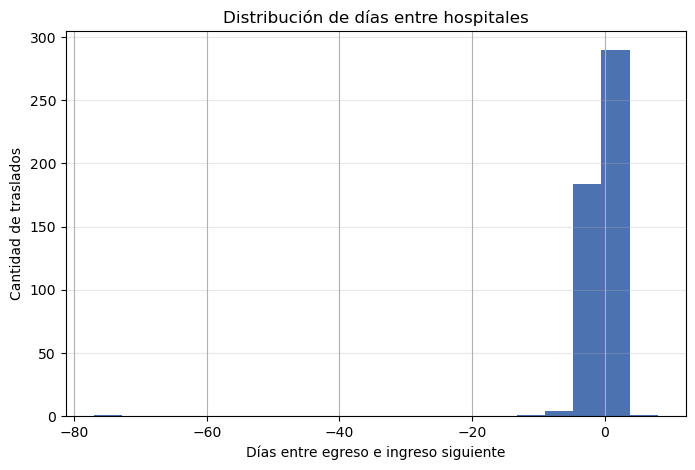

In [76]:
plt.figure(figsize=(8,5))
dias.hist(bins=20, color="#4C72B0")
plt.title("Distribución de días entre hospitales")
plt.xlabel("Días entre egreso e ingreso siguiente")
plt.ylabel("Cantidad de traslados")
plt.grid(axis='y', alpha=0.3)
plt.show()

## Problema que encontre:
hay algunos casos donde me estan dando tiempos negativos de traslados. Estudiarlo mas

In [77]:
# Ver qué filas generan negativos

negativos = traslados[traslados["dias_entre_hospitales"] < 0][[
    "Id",
    "Nombre Hospital",
    "Hospital siguiente",
    "Fecha egreso",
    "Fecha ingreso siguiente",
    "Motivo",
    "dias_entre_hospitales"
]]

print(len(negativos), "traslados con días negativos entre hospitales")
print(len(traslados), "traslados totales")
# mostrar las primeras filas
negativos.sort_values("dias_entre_hospitales").head(20)

190 traslados con días negativos entre hospitales
496 traslados totales


,Id,Nombre Hospital,Hospital siguiente,Fecha egreso,Fecha ingreso siguiente,Motivo,dias_entre_hospitales
6528,1,UPA 17 - QU,Oñativia,2020-08-03 18:07:36,2020-05-19 18:07:35,traslado-otro,-77.0
358,JX46,El Cruce,UPA 11 - FV,2020-09-29 18:07:34,2020-09-16 18:07:36,traslado-otro,-13.0
381,KM44,El Cruce,UPA 11 - FV,2020-10-01 18:07:34,2020-09-22 18:07:36,traslado-hospital-de-la-red,-9.0
414,XS83,El Cruce,UPA 11 - FV,2020-10-10 18:07:34,2020-10-01 18:07:36,traslado-extra-sanitario,-9.0
362,DY79,El Cruce,Mi Pueblo,2020-09-24 18:07:34,2020-09-16 18:07:34,traslado-hospital-de-la-red,-8.0
354,DE74,El Cruce,UPA 11 - FV,2020-09-21 18:07:34,2020-09-15 18:07:36,traslado-otro,-6.0
3506,4,Oñativia,UPA 17 - QU,2020-06-11 18:07:35,2020-06-08 18:07:36,traslado-extra-sanitario,-3.0
3064,OR60,Lucio Meléndez,Módulo Hospitalario 9 - AB,2020-08-10 18:07:35,2020-08-08 18:07:35,traslado-hospital-de-la-red,-2.0
4635,UW61,Módulo Hospitalario 9 - AB,UPA 5 - AB,2020-09-22 18:07:35,2020-09-20 18:07:35,traslado-otro,-2.0
4203,XG82,Oñativia,El Cruce,2020-09-19 18:07:35,2020-09-18 18:07:34,traslado-hospital-de-la-red,-2.0


In [78]:
# Contar cuántos negativos son realmente traslados

neg_traslados = negativos[negativos["Motivo"].str.contains("traslado", case=False, na=False)]
print("Negativos que son traslados reales:", len(neg_traslados))

Negativos que son traslados reales: 190


In [79]:
# opciones para resolver

# 1. Ignorar valores negativos (para análisis de tiempos promedio entre hospitales):
traslados["dias_entre_hospitales"] = traslados["dias_entre_hospitales"].clip(lower=0)
# 2. Eliminar los traslados raros
traslados = traslados[~((traslados["dias_entre_hospitales"] < 0) & (traslados["Motivo"].str.contains("traslado", case=False, na=False)))]
# 3. Ver caso por caso que paso

# OUTPUTS

In [ ]:
import os

# ruta de la carpeta results/2_3_2026
results_dir = "../results/2_3_2026"
os.makedirs(results_dir, exist_ok=True)

Registros luego de filtros: 481
Hospitales origen únicos: 12
Hospitales destino únicos: 12
Nodos en red: 13
Aristas en red: 38


<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

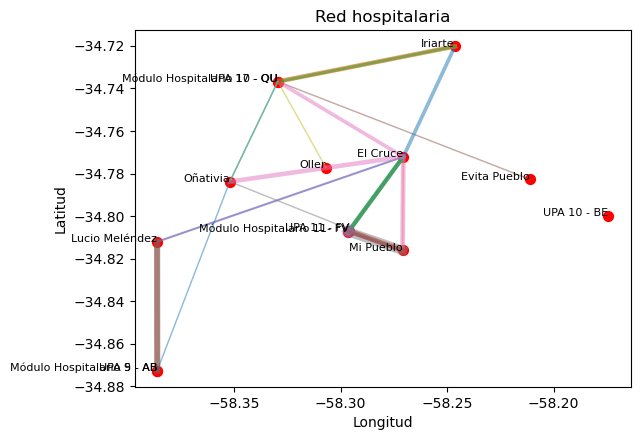

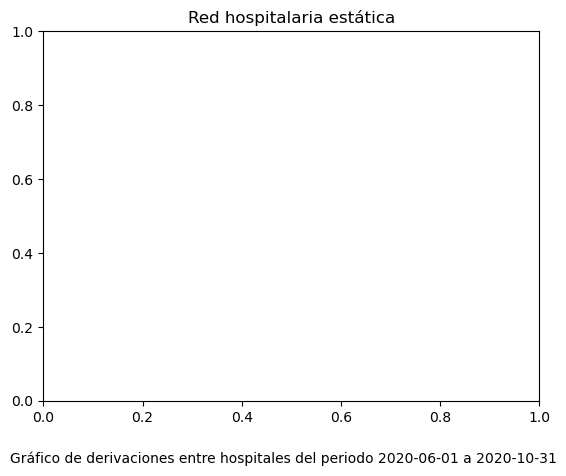

(<networkx.classes.digraph.DiGraph at 0x1a90f1e1cd0>,
                 Nombre Hospital           Hospital siguiente  weight
 0                      El Cruce               Lucio Meléndez       1
 1                      El Cruce                    Mi Pueblo       1
 2                      El Cruce  Módulo Hospitalario  9 - AB       1
 3                      El Cruce   Módulo Hospitalario 11- FV       5
 4                      El Cruce                  UPA 11 - FV       5
 5                  Evita Pueblo  Módulo Hospitalario 10 - QU       1
 6                       Iriarte                     El Cruce       5
 7                       Iriarte  Módulo Hospitalario 10 - QU       8
 8                       Iriarte                  UPA 17 - QU       3
 9                Lucio Meléndez                     El Cruce       2
 10               Lucio Meléndez  Módulo Hospitalario  9 - AB      47
 11               Lucio Meléndez                   UPA 5 - AB      12
 12                    Mi Pueblo    

In [108]:
# version estatica completa
analizar_red_hospitalaria(
    traslados,
    hosp_coords,
    fecha_inicio="2020-06-01",
    fecha_fin="2020-10-31",
    modo="estatico",
    guardar_path=results_dir+"/red_estatica.png",
    titulo="Red hospitalaria estática",
    caption="Gráfico de derivaciones entre hospitales del periodo 2020-06-01 a 2020-10-31"
)

Registros luego de filtros: 481
Hospitales origen únicos: 12
Hospitales destino únicos: 12
Nodos en red: 13
Aristas en red: 38


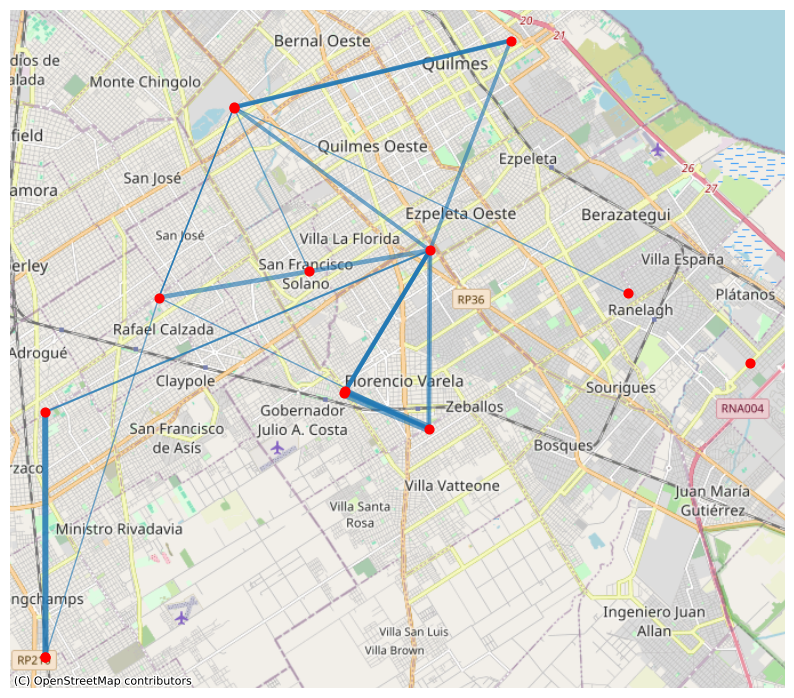

In [82]:
# Plotear estatico en el mapa
G, edges = analizar_red_hospitalaria(
    traslados,
    hosp_coords,
    fecha_inicio="2020-06-01",
    fecha_fin="2020-10-31",
    modo="mapa"
)
plt.title("Red hospitalaria sobre mapa", fontsize=16)
plt.figtext(0.5, -0.02, "Red hospitalaria proyectada sobre mapa base OpenStreetMap", ha="center", fontsize=10)

plt.savefig(os.path.join(results_dir, "red_mapa.png"), dpi=300)
plt.close()

In [83]:
# mapa interactivo exportable
m = analizar_red_hospitalaria(
    traslados,
    hosp_coords,
    fecha_inicio="2020-06-01",
    fecha_fin="2020-10-31",
    modo="interactivo"
)

m.save(os.path.join(results_dir, "red_interactiva.html"))

Registros luego de filtros: 481
Hospitales origen únicos: 12
Hospitales destino únicos: 12
Nodos en red: 13
Aristas en red: 38


Registros luego de filtros: 481
Hospitales origen únicos: 12
Hospitales destino únicos: 12
Nodos en red: 13
Aristas en red: 38


<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

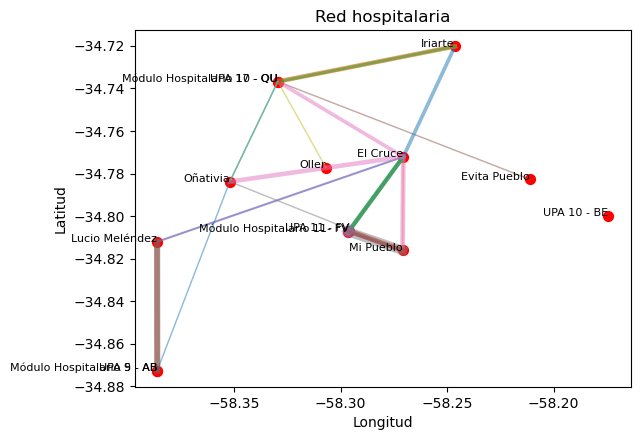

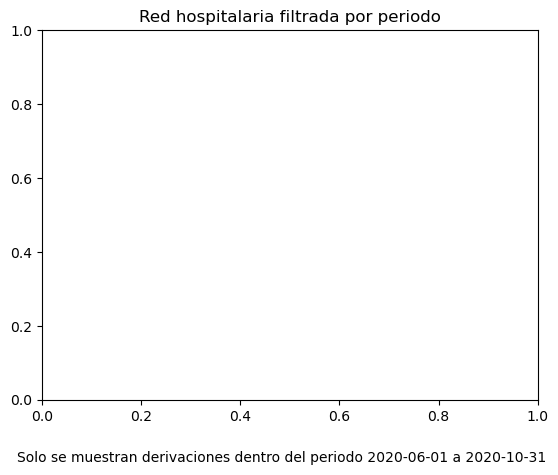

(<networkx.classes.digraph.DiGraph at 0x1a90f284110>,
                 Nombre Hospital           Hospital siguiente  weight
 0                      El Cruce               Lucio Meléndez       1
 1                      El Cruce                    Mi Pueblo       1
 2                      El Cruce  Módulo Hospitalario  9 - AB       1
 3                      El Cruce   Módulo Hospitalario 11- FV       5
 4                      El Cruce                  UPA 11 - FV       5
 5                  Evita Pueblo  Módulo Hospitalario 10 - QU       1
 6                       Iriarte                     El Cruce       5
 7                       Iriarte  Módulo Hospitalario 10 - QU       8
 8                       Iriarte                  UPA 17 - QU       3
 9                Lucio Meléndez                     El Cruce       2
 10               Lucio Meléndez  Módulo Hospitalario  9 - AB      47
 11               Lucio Meléndez                   UPA 5 - AB      12
 12                    Mi Pueblo    

In [110]:
# por periodo especifico, en este caso junio a octubre 2020
analizar_red_hospitalaria(
    traslados,
    hosp_coords,
    fecha_inicio="2020-06-01",
    fecha_fin="2020-10-31",
    modo="estatico",
    guardar_path=results_dir+"/red_periodo.png",
    titulo="Red hospitalaria filtrada por periodo",
    caption="Solo se muestran derivaciones dentro del periodo 2020-06-01 a 2020-10-31"
)

Registros luego de filtros: 481
Hospitales origen únicos: 12
Hospitales destino únicos: 12
Nodos en red: 13
Aristas en red: 38


<Figure size 1200x1200 with 0 Axes>

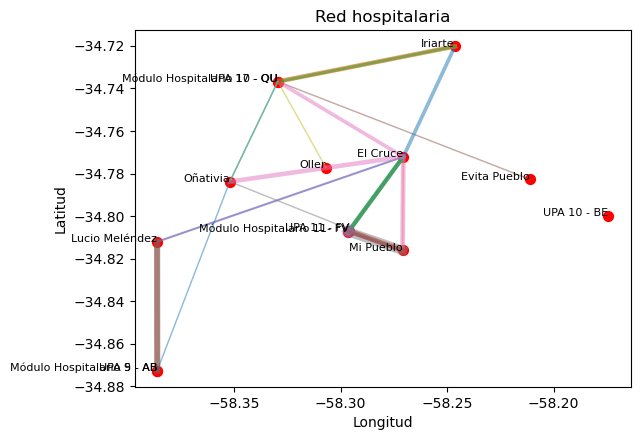

In [85]:
#limpiando negativos o casos que aun no sabemos
df_limpio = traslados[~((traslados["dias_entre_hospitales"] < 0) & (traslados["Motivo"].str.contains("traslado", case=False, na=False)))]
G_limpio, edges_limpio = analizar_red_hospitalaria(
    df_limpio,
    hosp_coords,
    fecha_inicio="2020-06-01",
    fecha_fin="2020-10-31",
    modo="estatico"
)
plt.title("Red hospitalaria sin traslados negativos raros", fontsize=16)
plt.figtext(0.5, -0.02, "Se eliminaron traslados con días negativos para limpiar la red", ha="center", fontsize=10)

plt.savefig(os.path.join(results_dir, "red_sin_negativos.png"), dpi=300)
plt.close()